In [ ]:
from pathlib import Path
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import RCP_analysis as rcp
import numpy as np
# import spikeinterface as si

# ------------ USER INPUTS ------------
FILE = Path('/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/Nike_UA_S1/Blackrock/Nike_UA_S1_002')

REPO_ROOT = Path().resolve().parents[1]
PARAMS    = rcp.load_experiment_params(REPO_ROOT / "config" / "params.yaml", repo_root=REPO_ROOT)

SESSION_LOC = (Path(PARAMS.data_root) / Path(PARAMS.location)).resolve()
OUT_BASE  = SESSION_LOC / "results"; OUT_BASE.mkdir(parents=True, exist_ok=True)
BR_ROOT = SESSION_LOC / "Blackrock"; BR_ROOT.mkdir(parents=True, exist_ok=True)
METADATA_ROOT = SESSION_LOC / "Metadata"; METADATA_ROOT.mkdir(parents=True, exist_ok=True)
METADATA_CSV  = METADATA_ROOT / f"{Path(PARAMS.session)}_metadata.csv"
SHIFT_CSV = METADATA_ROOT / "br_to_intan_shifts.csv"

BR_SESSION_FOLDERS = rcp.list_br_sessions(BR_ROOT)

RATES = PARAMS.UA_rate_est
BIN_MS     = float(RATES.get("bin_ms", 1.0))
SIGMA_MS   = float(RATES.get("sigma_ms", 50.0))
THRESH     = float(RATES.get("detect_threshold", 3))
PEAK_SIGN  = str(RATES.get("peak_sign", "both"))

ARTREMV_MS_BEFORE = 5.0
ARTCORR_TAIL_MS   = 5.0
    
XLS = rcp.ua_excel_path(REPO_ROOT, PARAMS.probes)
UA_MAP = rcp.load_UA_mapping_from_excel(XLS) if XLS else None
if UA_MAP is None:
    raise RuntimeError("UA mapping required for mapping on NS6.")

# Sync channels
UA_CFG = PARAMS.probes.get("UA")
CAMERA_SYNC_CH = int(UA_CFG.get("camera_sync_ch", 134))
TRIANGLE_SYNC_CH = int(UA_CFG.get("triangle_sync_ch", 138))

UA_AUX_DATA = OUT_BASE / "aux_data" / "UA"
NPRW_AUX_DATA = OUT_BASE / "aux_data" / "NPRW"
UA_CKPT_OUT = OUT_BASE / "checkpoints" / "UA"; UA_CKPT_OUT.mkdir(parents=True, exist_ok=True)
NPRW_CKPT_ROOT = OUT_BASE / "checkpoints" / "NPRW"

def _anchor_from_shifts_row(row: dict) -> tuple[int, float]:
    """
    From a shifts row, return (anchor_sample_intan, fs_intan).
    If anchor_sample is missing, derive from anchor_ms.
    """
    fs_intan = float(row.get("fs_intan", 30000.0))
    if row.get("anchor_sample", "") != "":
        return int(row["anchor_sample"]), fs_intan
    if row.get("anchor_ms", "") != "":
        anchor_ms = float(row["anchor_ms"])
        return int(round(anchor_ms * 1e-3 * fs_intan)), fs_intan
    return 0, fs_intan

# global_job_kwargs = dict(n_jobs=PARAMS.parallel_jobs, chunk_duration=PARAMS.chunk)
# si.set_global_job_kwargs(**global_job_kwargs)

print(f"=== Session: {FILE.name} ===")
rec_ns6 = se.read_blackrock(FILE, stream_name = 'nsx6', all_annotations=True) # Load neural data

br_idx = int(FILE.name.split('_')[-1]) # resolve br index
n_channels = rec_ns6.get_num_channels()

rec_ns6, idx_rows, ua_elec, ua_nsp, ua_region, ua_region_names, ua_port = rcp.apply_ua_mapping_with_regions(rec_ns6, UA_MAP, br_idx, METADATA_CSV)
UA_probe = ua_region.copy()

rec_hp  = spre.highpass_filter(rec_ns6, freq_min=float(PARAMS.highpass_hz))
region_idx, elec_count = np.unique(UA_probe, return_counts=True)
print(" | ".join(f"{ua_region_names[v]}: {c}" for v, c in zip(region_idx, elec_count)))

=== Session: Nike_UA_S1_002 ===
[MAP] UA port from metadata: 'A'
[MAP] renamed 128/128 rows with UA mapping ('UAe###_NSP###') using port 'A'.
SMA: 30 | Dorsal premotor: 32 | M1 inferior: 31 | M1 superior: 35


In [3]:
rec_ns6

ChannelSliceRecording: 128 channels - 30.0kHz - 4 segments - 13,770,906 samples 
                       459.03s (7.65 minutes) - int16 dtype - 3.28 GiB
Segments:
Samples:   13,653,336 | 76,415 | 2,080 | 39,075
Durations: 455.11s (7.59 minutes) | 2.55s | 0.07s (69.33 ms) | 1.30s
Memory:    3.26 GiB | 18.66 MiB | 520.00 KiB | 9.54 MiB

In [2]:
from pathlib import Path
import numpy as np
import RCP_analysis as rcp
%matplotlib inline
from matplotlib import pyplot as plt

# ---------- CONFIG ----------
REPO_ROOT = Path().resolve().parents[0]
PARAMS    = rcp.load_experiment_params(REPO_ROOT / "config" / "params.yaml", repo_root=REPO_ROOT)

SESSION_LOC = (Path(PARAMS.data_root) / Path(PARAMS.location)).resolve()
OUT_BASE  = SESSION_LOC / "results"; OUT_BASE.mkdir(parents=True, exist_ok=True)
METADATA_ROOT = SESSION_LOC / "Metadata"; METADATA_ROOT.mkdir(parents=True, exist_ok=True)
METADATA_CSV  = METADATA_ROOT / f"{Path(PARAMS.session)}_metadata.csv"

RATES_ALL_PATH = '/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/Target_A/peristim__NRR_RW011_251203_141346__BR_005_target_A.npz'

peristim_npz = np.load(RATES_ALL_PATH, allow_pickle=True)
cam0      = peristim_npz["beh_cam0_segs"]
NPRW_rates_zeroed = peristim_npz["NPRW_rates_zeroed"]
NPRW_counts = peristim_npz["NPRW_counts"]
NPRW_rel_t     = peristim_npz["NPRW_rel_t"]
UA_rates_zeroed    = peristim_npz["UA_rates_zeroed"]
UA_counts    = peristim_npz["UA_counts"]
UA_rel_t     = peristim_npz["UA_rel_t"]

In [43]:
peristim_npz.files[20:]

['n_vog_trials',
 'ts_state_rel_t',
 'ts_state_segs',
 'ts_state_char_segs',
 'ts_state_char',
 'ts_state_num',
 'n_ts_state_trials',
 'trial_labels',
 'NPRW_med',
 'NPRW_var',
 'NPRW_rates_zeroed',
 'NPRW_counts',
 'NPRW_rel_t',
 'n_nprw',
 'UA_med',
 'UA_var',
 'UA_rates_zeroed',
 'UA_counts',
 'UA_rel_t',
 'n_ua',
 'ua_ids_1based',
 'ua_region',
 'ua_region_names',
 'ua_port',
 'ua_nsp',
 'ua_idx_rows']

In [12]:
import numpy as np

# ----- config for smoothing -----
SIGMA_MS = 20.0      # e.g. 20 ms smoothing
BIN_MS   = 20.0      # or 50.0, whatever your peri-stim counts use

# (trials, ch, bins)
counts = UA_counts
blank_mask = np.zeros(counts.shape[2], dtype=bool)
UA_rates_smooth = np.empty_like(counts, dtype=float)

for trial in range(counts.shape[0]):
    counts_trial = counts[trial, :, :]
    rate_hz_trial = _smooth_counts_with_blanks(
        counts_trial,
        blank_mask=blank_mask,
        sigma_ms=SIGMA_MS,
        bin_ms=BIN_MS,
    )
    UA_rates_smooth[trial, :, :] = rate_hz_trial

print("UA_rates_smooth shape:", UA_rates_smooth.shape)

UA_rates_smooth shape: (6, 128, 60)


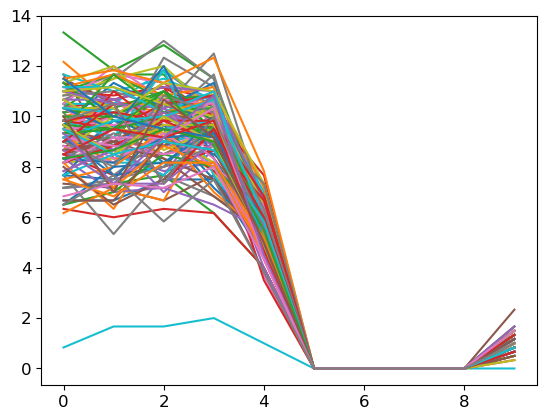

(128, 10)

In [37]:
plt.plot(np.nanmean(UA_counts, axis=0)[:, 25:35].T)
plt.show()
np.nanmean(UA_counts, axis=0)[:, 25:35].shape

(6, 128, 60)

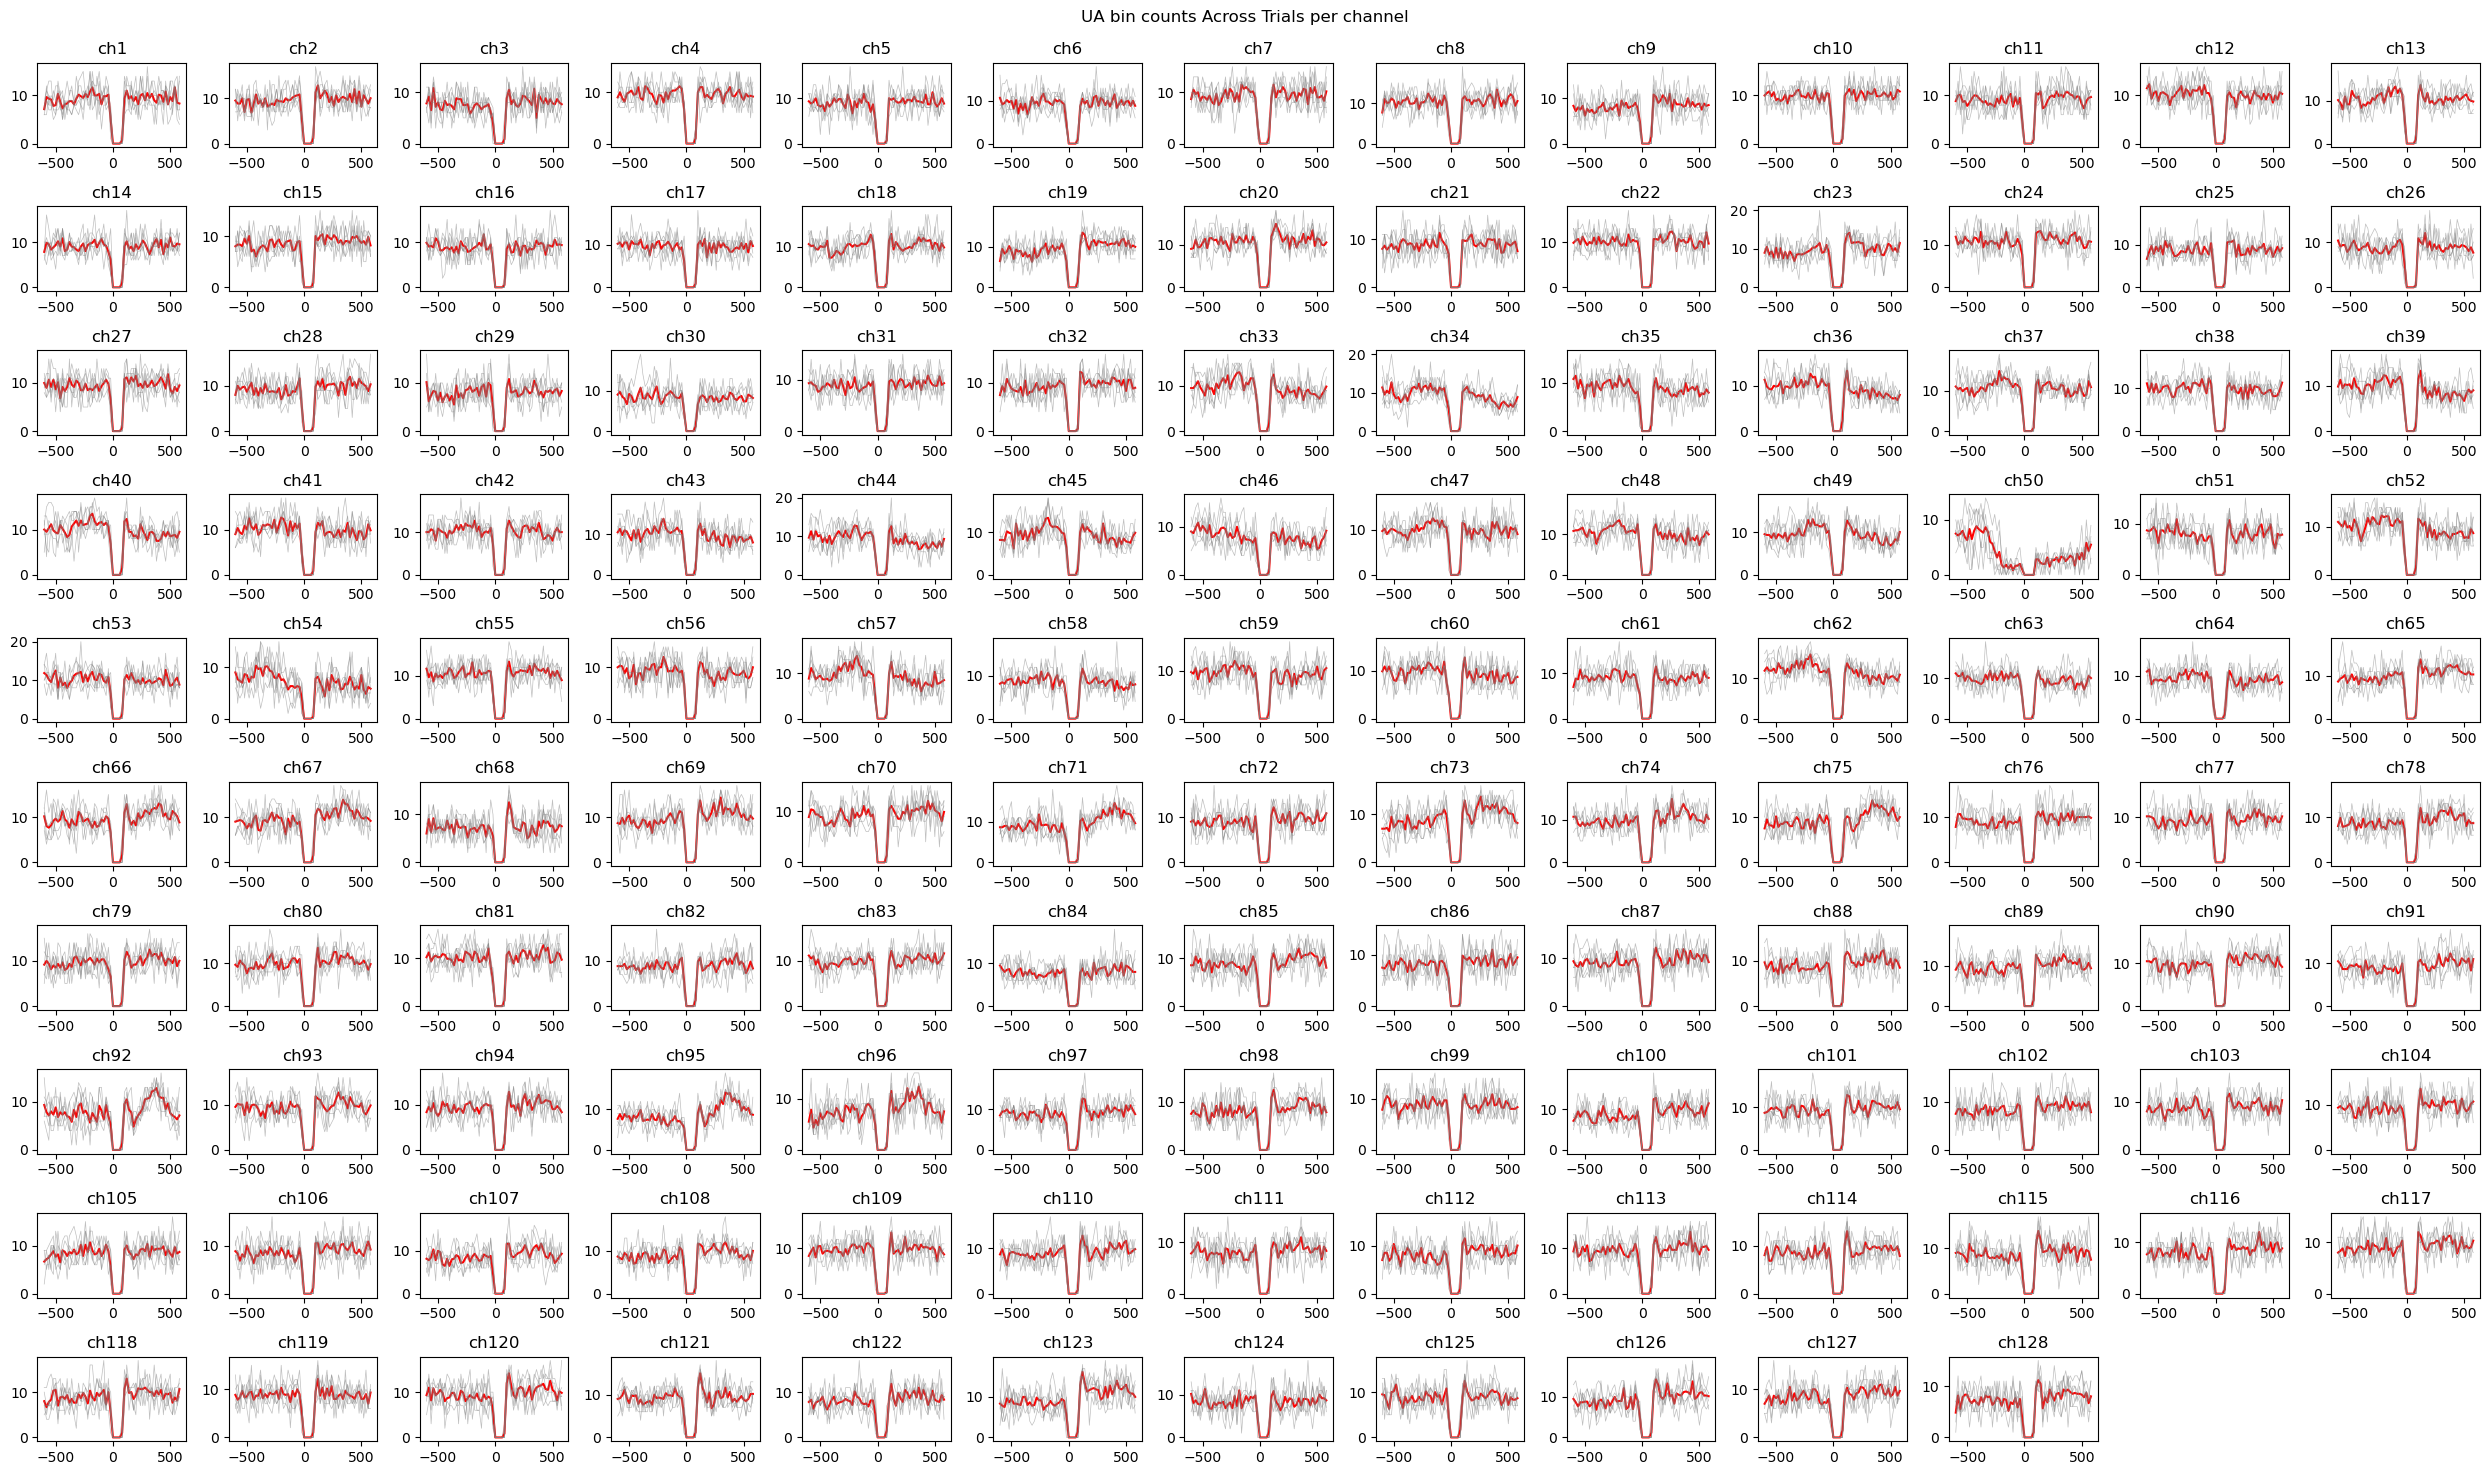

In [ ]:
plt.figure(figsize=(25, 15))
for ch_select in range(128):
    plt.subplot(10,13, ch_select+1)
    plt.plot(UA_rel_t, np.nanmean(UA_counts[:, ch_select, :], axis = 0).T,color="red")
    plt.plot(UA_rel_t, UA_counts[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.5)
    plt.title("ch" + str(ch_select + 1))
    
plt.suptitle("UA bin counts Across Trials per channel\n")
plt.tight_layout()

# UA_counts.shape

(6, 128, 60)

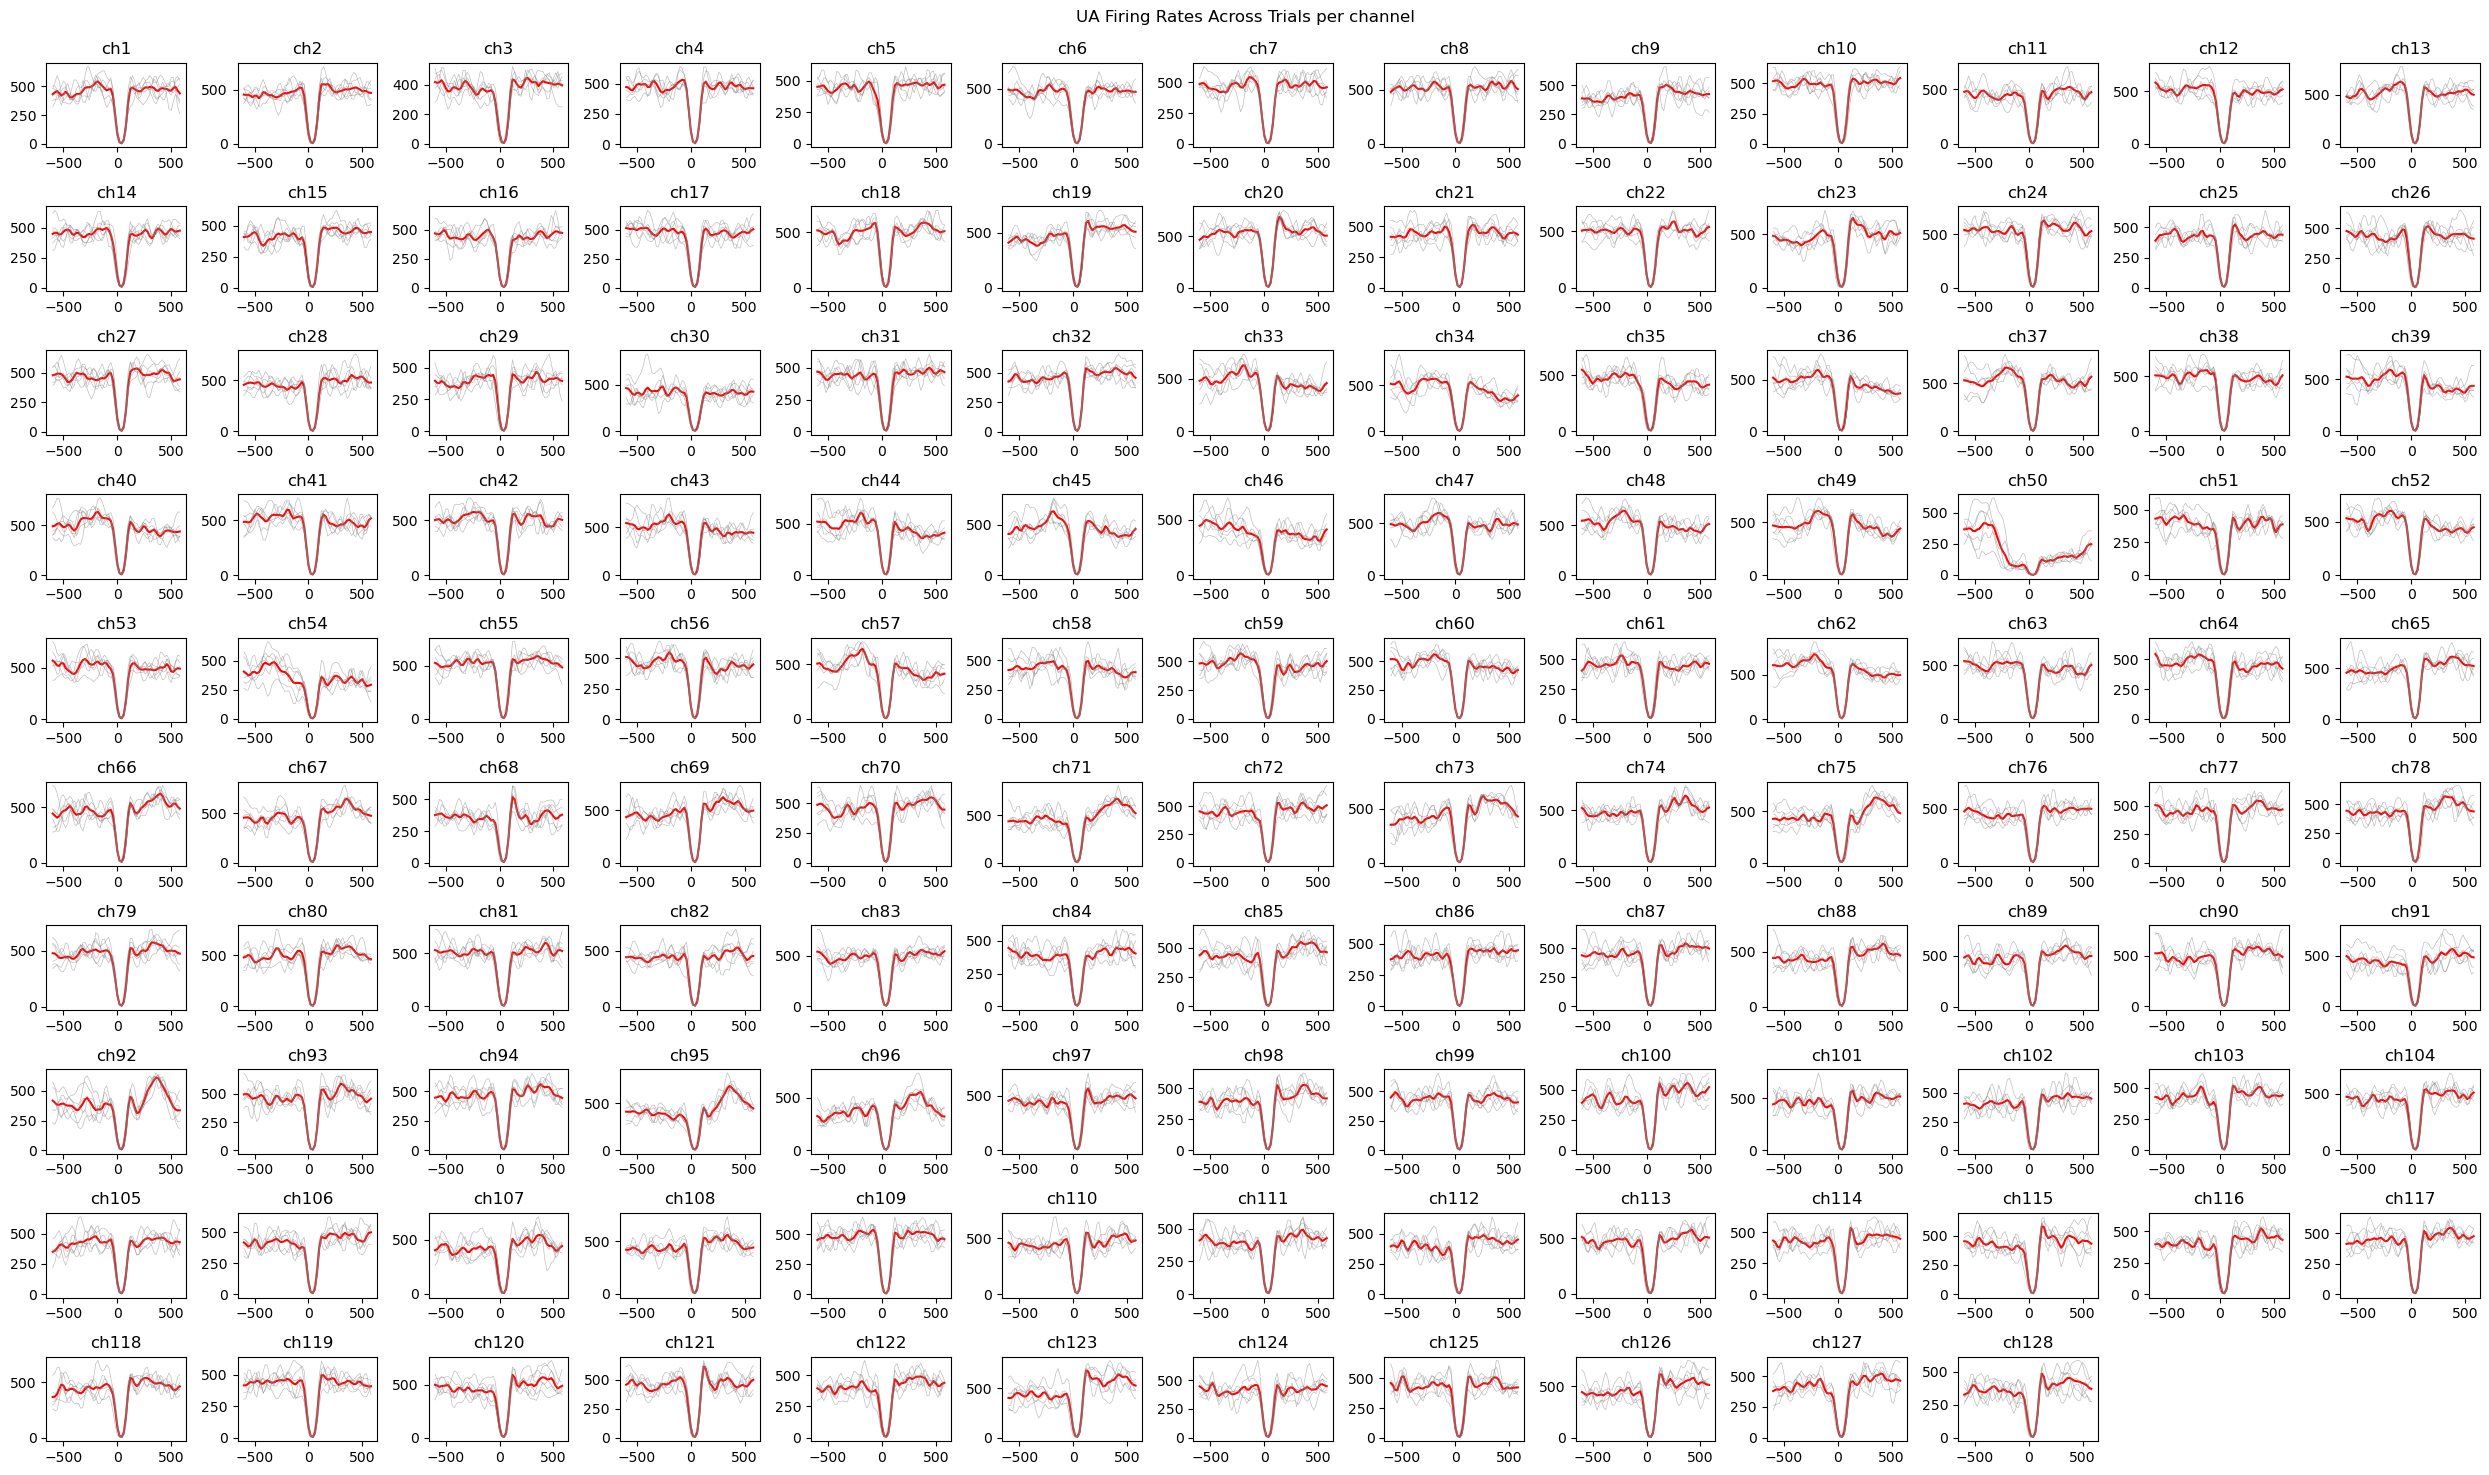

In [18]:
plt.figure(figsize=(25, 15))
for ch_select in range(128):
    plt.subplot(10,13, ch_select+1)
    plt.plot(UA_rel_t, np.nanmean(UA_rates_smooth[:, ch_select, :], axis = 0).T,color="red")
    plt.plot(UA_rel_t, UA_rates_smooth[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.5)
    plt.title("ch" + str(ch_select + 1))
    
plt.suptitle("UA Firing Rates Across Trials per channel\n")
plt.tight_layout()

UA_rates_smooth.shape

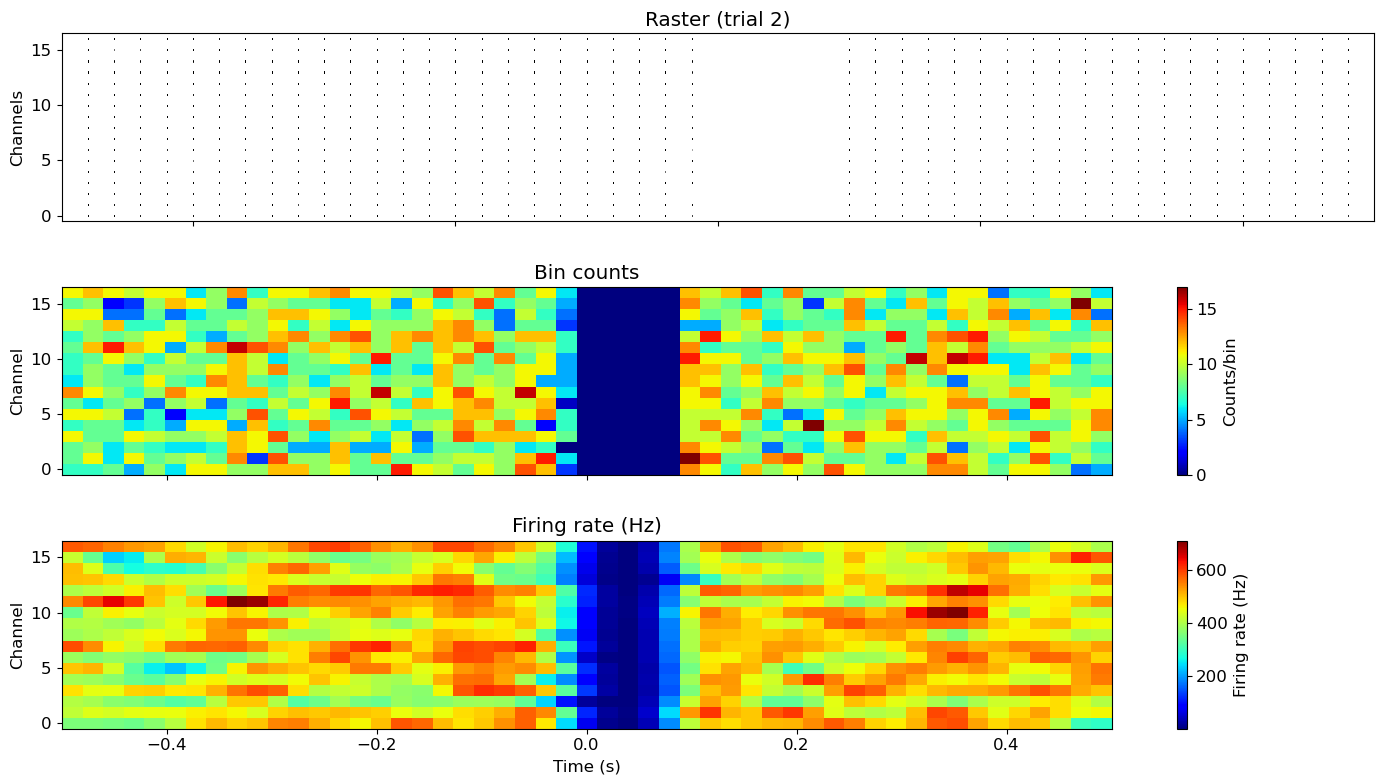

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# -------- choose trial and window (peri-stim, in seconds) --------
TRIAL_IDX = 2          # which trial to plot

T_START_S = -0.5       # window start (e.g., -0.5 s relative to stim)
WIN_LEN_S = 1.0        # window length (e.g., 1.0 s total)

T_END_S = T_START_S + WIN_LEN_S

# -------- pull shapes --------
# UA_counts, UA_rates_smooth: (n_trials, n_ch, n_bins)
n_trials, n_ch, n_bins = UA_counts.shape

# time axis for bins (assumed ms -> convert to seconds)
t_rel_ms = UA_rel_t           # shape (n_bins,)
t_rel_s  = t_rel_ms / 1000.0  # ms -> s

# -------- channel selection --------
N_CH_PLOT = min(17, n_ch)
ch_idx = np.arange(N_CH_PLOT)

# -------- window mask --------
time_mask = (t_rel_s >= T_START_S) & (t_rel_s <= T_END_S)
t_plot_s  = t_rel_s[time_mask]              # time in seconds in window

# per-trial slices
counts_trial = UA_counts[TRIAL_IDX]         # (n_ch, n_bins)
rate_trial   = UA_rates_smooth[TRIAL_IDX]   # (n_ch, n_bins)

rate_plot   = rate_trial[ch_idx][:, time_mask]      # (channels, timebins)
counts_plot = counts_trial[ch_idx][:, time_mask]    # (channels, timebins)

# -------- build pseudo-raster from binned counts --------
spikes_per_ch = []
for ch in ch_idx:
    ch_counts = counts_trial[ch, time_mask].astype(int)
    ch_spike_times = []
    for tb, c in enumerate(ch_counts):
        if c > 0:
            # put all spikes at the bin center time
            ch_spike_times.extend([t_plot_s[tb]] * c)
    spikes_per_ch.append(np.array(ch_spike_times, dtype=float))

# -------- plotting --------
plt.rcParams["font.size"] = 12

fig, (ax_raster, ax_counts, ax_fr) = plt.subplots(
    3, 1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1, 1]},
)

# --- top: raster ---
ax_raster.eventplot(
    spikes_per_ch,
    lineoffsets=ch_idx,
    linelengths=0.1,
    colors="black",
    linewidths=0.5,
    alpha=1.0,
)
ax_raster.set_xlim(T_START_S, T_END_S)
ax_raster.set_ylim(-0.5, N_CH_PLOT - 0.5)
ax_raster.set_yticks([0, 5, 10, 15])
ax_raster.set_ylabel("Channels")
ax_raster.set_title(f"Raster (trial {TRIAL_IDX})")
ax_raster.tick_params(axis="x", which="both", labelbottom=False)

# --- middle: bin counts heatmap ---
im_counts = ax_counts.imshow(
    counts_plot,
    aspect="auto",
    origin="lower",
    extent=[t_plot_s[0], t_plot_s[-1], -0.5, N_CH_PLOT - 0.5],
    cmap="jet",
)
ax_counts.set_xlim(T_START_S, T_END_S)
ax_counts.set_yticks([0, 5, 10, 15])
ax_counts.set_ylabel("Channel")
ax_counts.set_title("Bin counts")
ax_counts.tick_params(axis="x", which="both", labelbottom=False)
fig.colorbar(im_counts, ax=ax_counts, label="Counts/bin")

# --- bottom: firing-rate heatmap ---
im_fr = ax_fr.imshow(
    rate_plot,
    aspect="auto",
    origin="lower",
    extent=[t_plot_s[0], t_plot_s[-1], -0.5, N_CH_PLOT - 0.5],
    cmap="jet",
)
ax_fr.set_xlim(T_START_S, T_END_S)
ax_fr.set_yticks([0, 5, 10, 15])
ax_fr.set_ylabel("Channel")
ax_fr.set_xlabel("Time (s)")
ax_fr.set_title("Firing rate (Hz)")
fig.colorbar(im_fr, ax=ax_fr, label="Firing rate (Hz)")

fig.tight_layout()
fig.subplots_adjust(hspace=0.35)
plt.show()


/tmp/ipykernel_492104/2481435418.py:4: RuntimeWarning: Mean of empty slice
  plt.plot(NPRW_rel_t, np.nanmean(NPRW_rates_zeroed[:, ch_select, :], axis = 0).T,color="red")


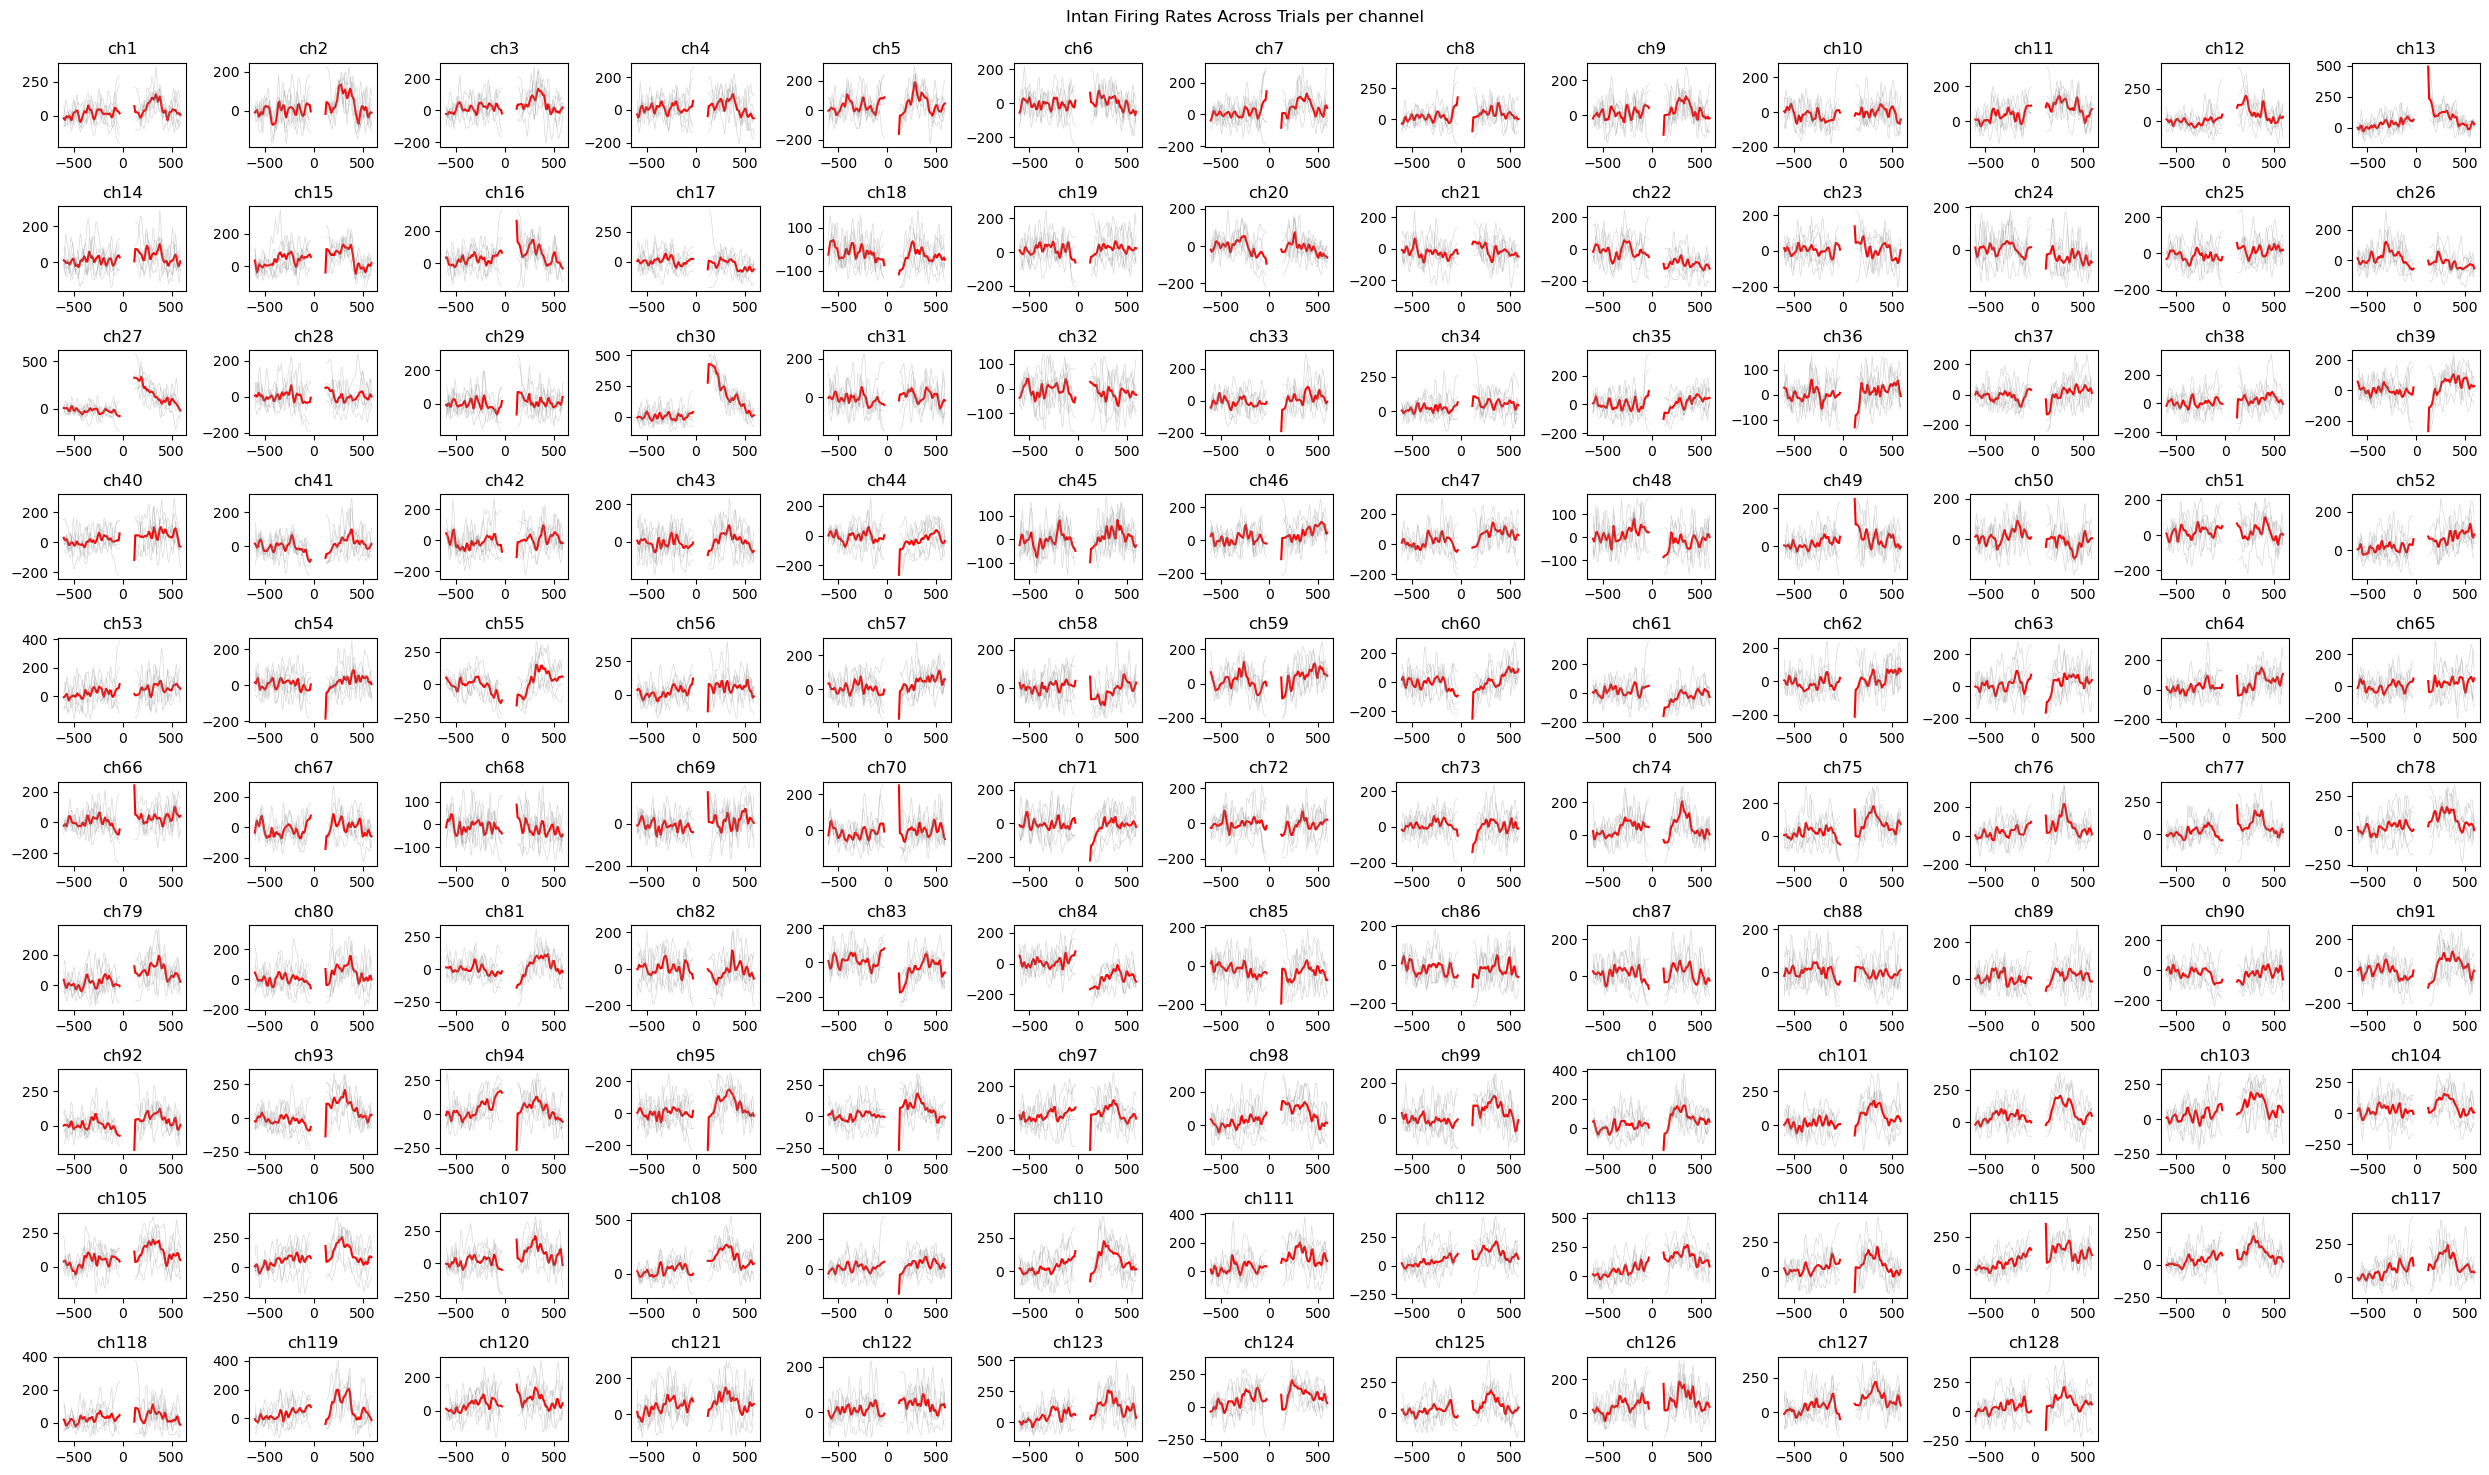

In [20]:
plt.figure(figsize=(25, 15))
for ch_select in range(128):
    plt.subplot(10, 13, ch_select+1)
    plt.plot(NPRW_rel_t, np.nanmean(NPRW_rates_zeroed[:, ch_select, :], axis = 0).T,color="red")
    plt.plot(NPRW_rel_t, NPRW_rates_zeroed[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.3)
    plt.title("ch" + str(ch_select + 1))
    
plt.suptitle("Intan Firing Rates Across Trials per channel\n")
plt.tight_layout()


In [ ]:
RATES_ALL_PATH = '/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/NRR_RW005/results/checkpoints/Aligned/aligned__NRR_RW005_251017_143721__Intan_003__BR_003.npz'

with np.load(RATES_ALL_PATH, allow_pickle=True) as peristim_npz:
    NPRW_zeroed = peristim_npz["intan_rate_hz"].astype(float) if "intan_rate_hz" in peristim_npz.files else np.zeros((0,0,0), float)
    UA_zeroed    = peristim_npz["ua_rate_hz"].astype(float)    if "ua_rate_hz"    in peristim_npz.files else np.zeros((0,0,0), float)
    NPRW_rel_t     = peristim_npz["intan_t_ms_aligned"].astype(float)  if "intan_t_ms_aligned"  in peristim_npz.files else np.arange(0.0)
    UA_rel_t     = peristim_npz["ua_t_ms_aligned"].astype(float)  if "ua_t_ms_aligned"  in peristim_npz.files else np.arange(0.0)

In [ ]:
UA_zeroed.shape

(128, 14612)

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

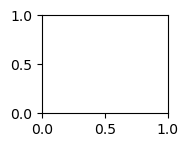

In [ ]:
plt.figure(figsize=(25, 15))
for ch_select in range(128):
    plt.subplot(10,13, ch_select+1)
    plt.plot(UA_rel_t, np.nanmean(UA_zeroed[:, ch_select, :], axis = 0).T,color="red")
    plt.plot(UA_rel_t, UA_zeroed[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.5)
    plt.title("ch" + str(ch_select + 1))
    
plt.suptitle("UA Firing Rates Across Trials per channel\n")
plt.tight_layout()

In [ ]:
plt.figure(figsize=(25, 15))
for ch_select in range(128):
    plt.subplot(10, 13, ch_select+1)
    plt.plot(NPRW_rel_t, np.nanmean(NPRW_zeroed[:, ch_select, :], axis = 0).T,color="red")
    plt.plot(NPRW_rel_t, NPRW_zeroed[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.3)
    plt.title("ch" + str(ch_select + 1))
    
plt.suptitle("Intan Firing Rates Across Trials per channel\n")
plt.tight_layout()
